# Parity-Stratified Clustering of milk_kg × DIM (closing the parity confound)

**Why this notebook?** In `Clustering_FeaturePairs.ipynb` the pairs that *included* `parity` (and `AFC`, which tracks parity) scored the highest silhouette — but that was an **artifact**: `parity` is a discrete integer, so K-Means just cuts between the integer columns and silhouette rewards that trivially. It is not finding biological groups.

The honest version of the question is therefore:

> *Given the lactation number (parity), do buffalo separate into real production groups along the two genuinely continuous traits, `milk_kg` and `DIM`?*

So here we **stratify by parity** (1, 2, 3+) and cluster `milk_kg × DIM` *within each stratum*. This removes parity as a confound instead of feeding it in as a coordinate. If clear clusters appear inside a stratum, that is a real finding; if each stratum is still one continuous blob, that **confirms** the continuum conclusion in a way that directly answers the professors' objection.

Read-only on `../Thesis_Data/Final_Data/After_Processing.csv`; no existing file is modified.

In [1]:
import os
N_JOBS = max(1, (os.cpu_count() or 2) - 1)
for _v in ('OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS', 'NUMEXPR_NUM_THREADS'):
    os.environ.setdefault(_v, str(min(N_JOBS, 8)))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')
CONT_FEATS = ['milk_kg', 'DIM']    # the two genuinely continuous traits
print(f'Using up to {N_JOBS} cores')

Using up to 7 cores


In [2]:
# ---- Load (READ ONLY) ----
PATH = '../Thesis_Data/Final_Data/After_Processing.csv'
df = pd.read_csv(PATH, usecols=['Animal_ID', 'parity', 'DIM', 'milk_kg'])
df = df.dropna(subset=['parity', 'DIM', 'milk_kg'])
df = df[(df['milk_kg'] > 0) & (df['DIM'].between(1, 365))]

# Parity strata: 1, 2, and 3+ (later parities are sparse and biologically similar).
df['parity_stratum'] = np.where(df['parity'] >= 3, '3+', df['parity'].astype(int).astype(str))
STRATA = ['1', '2', '3+']
print(f'{len(df):,} records')
print(df['parity_stratum'].value_counts().reindex(STRATA))

1,646,809 records
parity_stratum
1     539429
2     399571
3+    707809
Name: count, dtype: int64


## Cluster milk_kg × DIM within each parity stratum

For each stratum: standardise the two traits, pick `k` by best silhouette, run K-Means, and plot on the real axes. The silhouette of each stratum is the headline number — if it stays low (~0.3–0.4, same as the un-stratified `milk_kg + DIM`), parity was never hiding real groups.

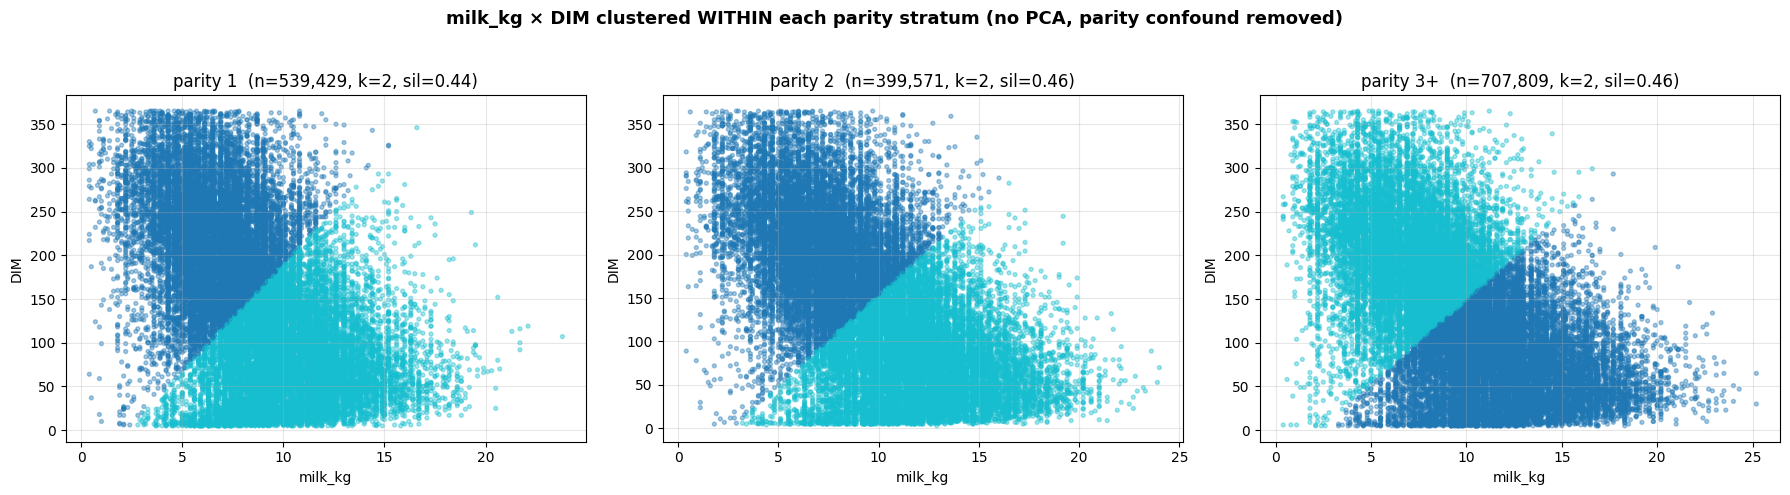

,parity_stratum,n,best_k,silhouette
0,1,539429,2,0.445
1,2,399571,2,0.463
2,3+,707809,2,0.457


In [3]:
def best_k(X, k_range=range(2, 9), sample=20000):
    Xs = X if len(X) <= sample else X[np.random.choice(len(X), sample, replace=False)]
    sils = [silhouette_score(Xs, KMeans(k, random_state=RANDOM_STATE, n_init=10).fit_predict(Xs)) for k in k_range]
    return list(k_range)[int(np.argmax(sils))], max(sils)


def scored_silhouette(X, labels, cap=50000):
    """Silhouette on a capped sample using the SAME rows for X and labels."""
    if len(set(labels)) < 2:
        return float('nan')
    return silhouette_score(X, labels, sample_size=min(cap, len(X)), random_state=RANDOM_STATE)


fig, axes = plt.subplots(1, 3, figsize=(18, 5))
summary = []
for ax, s in zip(axes, STRATA):
    sub = df[df['parity_stratum'] == s]
    X = StandardScaler().fit_transform(sub[CONT_FEATS].values)
    k, _ = best_k(X)
    km = KMeans(k, random_state=RANDOM_STATE, n_init=10).fit(X)
    sil = scored_silhouette(X, km.labels_)
    idx = np.random.choice(len(sub), min(30000, len(sub)), replace=False)
    ax.scatter(sub['milk_kg'].values[idx], sub['DIM'].values[idx], c=km.labels_[idx], cmap='tab10', s=8, alpha=0.4)
    ax.set(xlabel='milk_kg', ylabel='DIM', title=f'parity {s}  (n={len(sub):,}, k={k}, sil={sil:.2f})')
    ax.grid(alpha=0.3)
    summary.append({'parity_stratum': s, 'n': len(sub), 'best_k': k, 'silhouette': round(sil, 3)})
fig.suptitle('milk_kg × DIM clustered WITHIN each parity stratum (no PCA, parity confound removed)',
             fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
pd.DataFrame(summary)

## Density check (DBSCAN) within each stratum

K-Means will always return `k` clusters even if the data is one blob. DBSCAN does not: it reports how many *dense* groups actually exist and labels the rest as noise. If each stratum collapses to **one** dense cluster, the continuum conclusion is confirmed independently of K-Means.

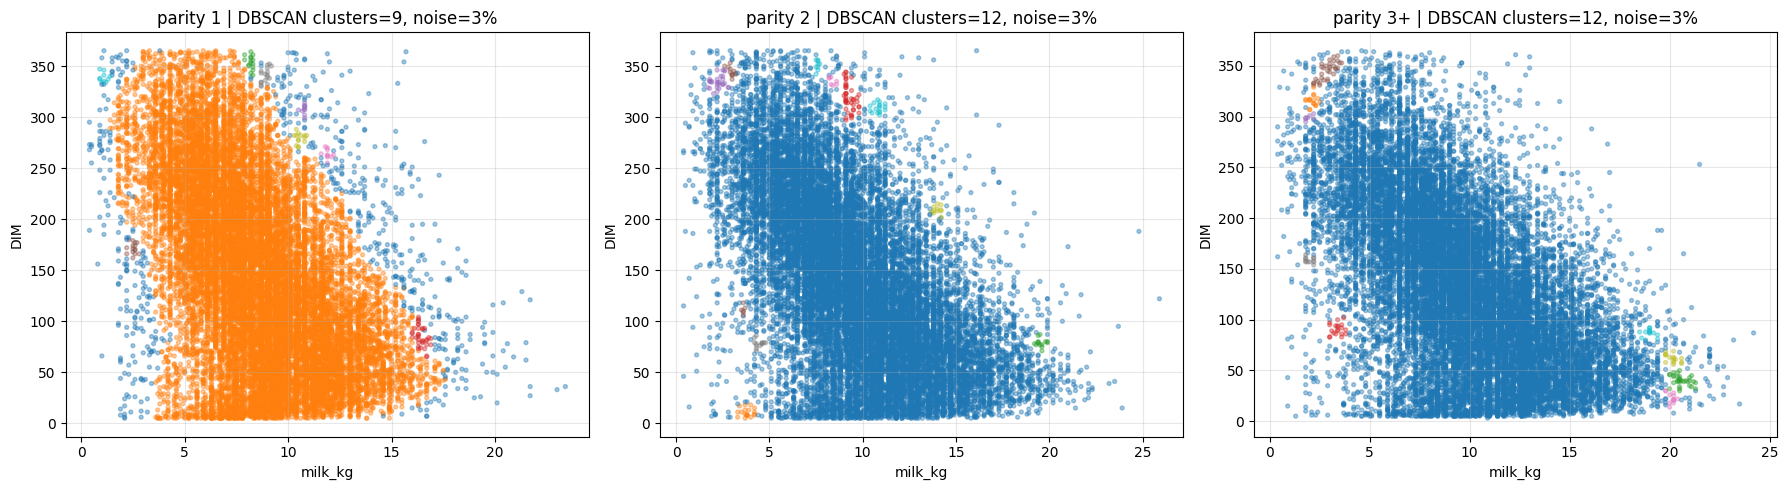

,parity_stratum,dbscan_clusters,noise_frac
0,1,9,0.029
1,2,12,0.028
2,3+,12,0.028


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
dbs = []
for ax, s in zip(axes, STRATA):
    sub = df[df['parity_stratum'] == s]
    X = StandardScaler().fit_transform(sub[CONT_FEATS].values)
    idx = np.arange(len(X)) if len(X) <= 20000 else np.random.choice(len(X), 20000, replace=False)
    Xs = X[idx]
    nn = NearestNeighbors(n_neighbors=10, n_jobs=N_JOBS).fit(Xs)
    eps = np.percentile(np.sort(nn.kneighbors(Xs)[0][:, -1]), 95)
    lab = DBSCAN(eps=eps, min_samples=10, n_jobs=N_JOBS).fit_predict(Xs)
    n_clusters = len(set(lab)) - (1 if -1 in lab else 0)
    noise = (lab == -1).mean()
    ax.scatter(sub['milk_kg'].values[idx], sub['DIM'].values[idx], c=lab, cmap='tab10', s=8, alpha=0.4)
    ax.set(xlabel='milk_kg', ylabel='DIM',
           title=f'parity {s} | DBSCAN clusters={n_clusters}, noise={noise:.0%}')
    ax.grid(alpha=0.3)
    dbs.append({'parity_stratum': s, 'dbscan_clusters': n_clusters, 'noise_frac': round(noise, 3)})
plt.tight_layout()
plt.show()
pd.DataFrame(dbs)

## Reading the result

- If within-stratum silhouettes stay around the un-stratified `milk_kg + DIM` level (~0.3–0.45) **and** DBSCAN returns a single dense cluster per stratum, then **parity was never masking real production groups** — the high silhouettes of the parity/AFC pairs were purely the discreteness artifact. This *confirms* the continuum finding from `Clustering_FeaturePairs.ipynb`.
- That is the clean answer to the professors' objection: with the confound removed and only real continuous traits clustered, the buffalo do not fall into discrete production types. The meaningful grouping must come from the **lactation-curve shape** instead (see `Clustering_CurveShape_Heat.ipynb`).